In [68]:
from collections.abc import Sequence
from dataclasses import dataclass
from pathlib import Path
from typing import NamedTuple, overload
from enum import Enum
from cv2.typing import MatLike
from IPython.display import clear_output, display
from matplotlib import pyplot as plt

import cv2
import numpy as np
import re


@dataclass(frozen=True)
class Metrics:
    tp: int
    tn: int
    fp: int
    fn: int

    def precision(self) -> float:
        if (buf := self.tp + self.fp) == 0:
            return 0.0
        return float(self.tp) / buf

    def recall(self) -> float:
        if (buf := self.tp + self.fn) == 0:
            return 0.0
        return float(self.tp) / buf

    def f1(self) -> float:
        precision = self.precision()
        recall = self.recall()
        if (buf := precision + recall) == 0:
            return 0.0
        return (2 * precision * recall) / buf

    @classmethod
    def compare_images(cls, pred: MatLike, groundtruth: MatLike) -> 'Metrics':
        return cls(
            tp=np.sum((groundtruth == 255) & (pred == 255)),
            tn=np.sum((groundtruth == 0) & (pred == 0)),
            fp=np.sum((groundtruth == 0) & (pred == 255)),
            fn=np.sum((groundtruth == 255) & (pred == 0)),
        )
    @classmethod
    def compare_sequences(cls, pred: Sequence[MatLike], groundtruth: Sequence[MatLike]) -> 'Metrics':
        tp = 0
        tn = 0
        fp = 0
        fn = 0

        for pred_img, groundtruth_img in zip(pred, groundtruth, strict=True):
            tp += np.sum((groundtruth_img == 255) & (pred_img == 255))
            tn += np.sum((groundtruth_img == 0) & (pred_img == 0))
            fp += np.sum((groundtruth_img == 0) & (pred_img == 255))
            fn += np.sum((groundtruth_img == 255) & (pred_img == 0))

        return cls(tp=tp, tn=tn, fp=fp, fn=fn)

class DataSet(Enum):
    HIGHWAY="highway"
    OFFICE="office"
    PEDESTRIAN="pedestrian"

class Roi(NamedTuple):
    start: int
    end: int

def _sorted_frame_paths(directory: Path, prefix: str) -> list[Path]:
    pattern = re.compile(rf"^{re.escape(prefix)}(\d+)$")
    indexed_paths = []
    for path in directory.iterdir():
        if not path.is_file():
            continue
        match = pattern.fullmatch(path.stem)
        if match is None:
            continue
        indexed_paths.append((int(match.group(1)), path))
    return [path for _, path in sorted(indexed_paths, key=lambda item: item[0])]

def load_img_sequence(data_set: DataSet, *flags: int) -> Sequence[MatLike]:
    dataset_dir = Path(__name__).parent.resolve()/"data"/f"{data_set.value}"/"input"
    return [np.astype(img, np.int16) for file_name in _sorted_frame_paths(dataset_dir, "in") if (img := cv2.imread(file_name, *flags)) is not None]

def load_img_sequence_results(data_set: DataSet) -> Sequence[MatLike]:
    dataset_dir = Path(__name__).parent.resolve()/"data"/f"{data_set.value}"/"groundtruth"
    return [np.astype((img==255)*255, np.int16) for file_name in _sorted_frame_paths(dataset_dir, "gt") if (img := cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)) is not None]

def load_roi(data_set: DataSet) -> Roi:
    roi = Path(__name__).parent.resolve()/"data"/f"{data_set.value}"/"temporalROI.txt"
    return Roi(*[int(v) for v in roi.read_text("utf-8").split(" ")])

def normalize_frame_size(img_sequence: Sequence[MatLike]) -> tuple[list[MatLike], tuple[int, int]]:
    first_frame = next(iter(img_sequence), None)
    if first_frame is None:
        raise ValueError("img_sequence must contain at least one frame")

    target_height, target_width = first_frame.shape[:2]
    normalized_frames = [np.ascontiguousarray(np.clip(first_frame, 0, 255).astype(np.uint8, copy=False))]

    for img in img_sequence[1:]:
        if img.shape[:2] != (target_height, target_width):
            img = cv2.resize(img, (target_width, target_height), interpolation=cv2.INTER_LINEAR)
        normalized_frames.append(np.ascontiguousarray(np.clip(img, 0, 255).astype(np.uint8, copy=False)))

    return normalized_frames, (target_height, target_width)


def show_img(img: MatLike, cmap: str | None = None) -> None:
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap=cmap, vmin=0, vmax=255)
    plt.axis("off")
    plt.show()


@overload
def show_sequence(img_sequence: Sequence[MatLike], cmap: str | None = None, wait_time: float = 1, titles: str | None = None) -> None:
    ...
@overload
def show_sequence(img_sequence: Sequence[Sequence[MatLike]], cmap: str | None | Sequence[str | None] = None, wait_time: float = 1, titles: Sequence[str] | None = None) -> None:
    ...

def show_sequence(img_sequence: Sequence[MatLike] | Sequence[Sequence[MatLike]], cmap: str | None | Sequence[str | None] = None, wait_time: float = 1, titles: str | Sequence[str] | None = None) -> None:
    first_item = next(iter(img_sequence), None)
    if first_item is None:
        return

    is_multi_sequence = isinstance(first_item, Sequence)

    if is_multi_sequence:
        sequences = [list(sequence) for sequence in img_sequence]
        if any(len(sequence) != len(sequences[0]) for sequence in sequences[1:]):
            raise ValueError("All sequences must have the same length")
        if len(sequences[0]) == 0:
            return

        if titles is None:
            subplot_titles = [None] * len(sequences)
        else:
            if isinstance(titles, str):
                raise TypeError("titles must be a sequence of strings for multiple sequences")
            subplot_titles = list(titles)
            if len(subplot_titles) != len(sequences):
                raise ValueError("Number of titles must match number of sequences")

        if cmap is None or isinstance(cmap, str):
            cmaps = [cmap] * len(sequences)
        else:
            cmaps = list(cmap)
            if len(cmaps) != len(sequences):
                raise ValueError("Number of cmaps must match number of sequences")

        fig, axes = plt.subplots(1, len(sequences), figsize=(4 * len(sequences), 4))
        axes = np.atleast_1d(axes)
        images = []

        for ax, sequence, title, sequence_cmap in zip(axes, sequences, subplot_titles, cmaps, strict=True):
            vmin = 0 if sequence_cmap=='gray' else None
            vmax = 255 if sequence_cmap=='gray' else None
            images.append(ax.imshow(sequence[0], cmap=sequence_cmap, vmin=vmin, vmax=vmax))
            if title is not None:
                ax.set_title(title)
            ax.axis("off")

        try:
            display(fig)
            plt.pause(wait_time)

            for frames in zip(*(sequence[1:] for sequence in sequences), strict=True):
                for image, frame in zip(images, frames, strict=True):
                    image.set_data(frame)
                clear_output(wait=True)
                display(fig)
                plt.pause(wait_time)
        finally:
            plt.close(fig)
        return

    frames = iter(img_sequence)
    first_frame = next(frames)

    fig, ax = plt.subplots(figsize=(4, 4))
    if cmap is not None and not isinstance(cmap, str):
        raise TypeError("cmap must be a single value for a single sequence")
    image = ax.imshow(first_frame, cmap=cmap, vmin=0, vmax=255)
    if titles is not None:
        if not isinstance(titles, str):
            raise TypeError("titles must be a string for a single sequence")
        ax.set_title(titles)
    ax.axis("off")

    try:
        display(fig)
        plt.pause(wait_time)

        for img in frames:
            image.set_data(img)
            clear_output(wait=True)
            display(fig)
            plt.pause(wait_time)
    finally:
        plt.close(fig)

# 3. Segmentacja obiektów pierwszoplanowych

## 3.3. Metody oparte o bufor próbek

In [2]:
pedestrian_start, pedestrian_stop = load_roi(DataSet.PEDESTRIAN)
pedestrian_sequence = load_img_sequence(DataSet.PEDESTRIAN, cv2.IMREAD_GRAYSCALE)
pedestrian_sequence = pedestrian_sequence[pedestrian_start: pedestrian_stop+1]
pedestrian_groundtruth = load_img_sequence_results(DataSet.PEDESTRIAN)
pedestrian_groundtruth = pedestrian_groundtruth[pedestrian_start: pedestrian_stop+1]

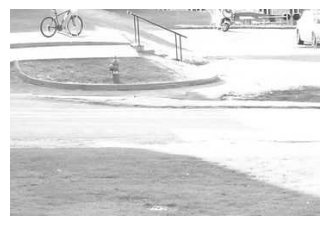

In [4]:
show_sequence(pedestrian_sequence, wait_time=1/60, cmap="gray")

In [3]:
from collections import deque
import enum
from functools import partial

class FuncType(Enum):
    MEAN=enum.member(partial(np.mean, axis=0))
    MEDIAN=enum.member(partial(np.median, axis=0))

def bufor_method(
    sequence: Sequence[MatLike],
    bufor_size: int = 60,
    func: FuncType = FuncType.MEAN,
) -> Sequence[MatLike]:
    assert len(sequence[0].shape) == 2, "Images must have only one channel"
    buf = deque([sequence[0].astype(np.uint8)]*bufor_size, maxlen=bufor_size)
    diff_results = []
    for frame in sequence:
        buf.append(frame.astype(np.uint8))
        model_value = func.value(buf)
        diff = cv2.absdiff(frame.astype(np.uint8), model_value.astype(np.uint8))
        diff_results.append(diff)
    binary_result = [cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)[1] for diff in diff_results]
    median_result = [cv2.medianBlur(bin, 3) for bin in binary_result]
    close_result = [cv2.morphologyEx(median, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)), iterations=2) for median in median_result]
    return close_result

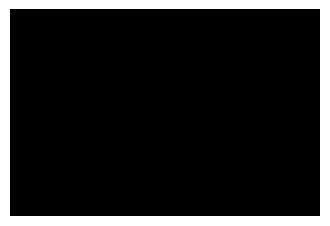

In [44]:
pedestrian_result = bufor_method(pedestrian_sequence, func=FuncType.MEDIAN)
show_sequence(pedestrian_result, 'gray', 1/60)

In [7]:
result = Metrics.compare_sequences(pedestrian_result, pedestrian_groundtruth)

In [8]:
print(f"{result.precision() = :.2f}")
print(f"{result.recall() = :.2f}")
print(f"{result.f1() = :.2f}")

result.precision() = 0.53
result.recall() = 0.99
result.f1() = 0.69


In [4]:
def pipeline_3_1(dataset: DataSet) -> tuple[Sequence[MatLike], ...]:
    dataset_start, dataset_stop = load_roi(dataset)
    dataset_sequence = load_img_sequence(dataset, cv2.IMREAD_GRAYSCALE)
    dataset_sequence = dataset_sequence[dataset_start: dataset_stop+1]
    dataset_groundtruth = load_img_sequence_results(dataset)
    dataset_groundtruth = dataset_groundtruth[dataset_start: dataset_stop+1]

    dataset_mean_result = bufor_method(dataset_sequence)
    dataset_median_result = bufor_method(dataset_sequence, func=FuncType.MEDIAN)

    mean_metrics = Metrics.compare_sequences(dataset_mean_result, dataset_groundtruth)
    median_metrics = Metrics.compare_sequences(dataset_median_result, dataset_groundtruth)

    for method, metrics in zip(("Mean", "Median",), (mean_metrics, median_metrics,), strict=True):
        print(f"Results for {method}")
        print(f"\t {metrics.precision() = :.2f}")
        print(f"\t {metrics.recall() = :.2f}")
        print(f"\t {metrics.f1() = :.2f}")

    return (dataset_sequence, dataset_mean_result, dataset_median_result)

In [19]:
results = pipeline_3_1(DataSet.OFFICE)

Results for Mean
	 metrics.precision() = 0.52
	 metrics.recall() = 0.42
	 metrics.f1() = 0.46
Results for Median
	 metrics.precision() = 0.57
	 metrics.recall() = 0.37
	 metrics.f1() = 0.45


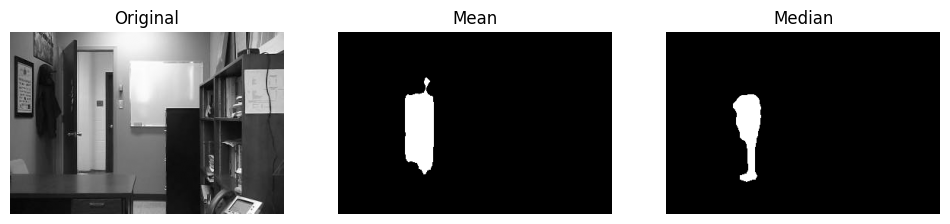

In [26]:
show_sequence(results, 'gray', 1/250, titles=("Original", "Mean", "Median",))

In [27]:
results = pipeline_3_1(DataSet.HIGHWAY)

Results for Mean
	 metrics.precision() = 0.49
	 metrics.recall() = 0.99
	 metrics.f1() = 0.65
Results for Median
	 metrics.precision() = 0.66
	 metrics.recall() = 0.99
	 metrics.f1() = 0.79


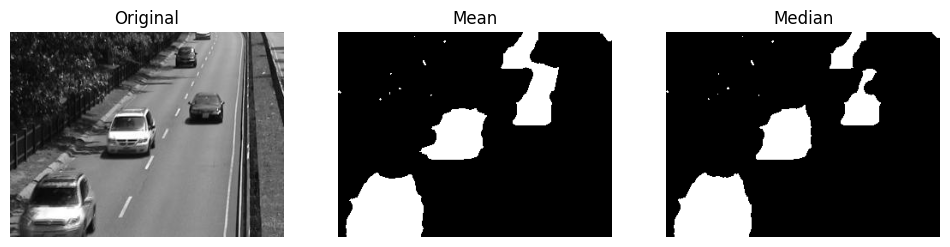

In [37]:
show_sequence(results, 'gray', 1/300, titles=("Original", "Mean", "Median",))

In [38]:
results = pipeline_3_1(DataSet.PEDESTRIAN)

Results for Mean
	 metrics.precision() = 0.44
	 metrics.recall() = 0.98
	 metrics.f1() = 0.61
Results for Median
	 metrics.precision() = 0.53
	 metrics.recall() = 0.99
	 metrics.f1() = 0.69


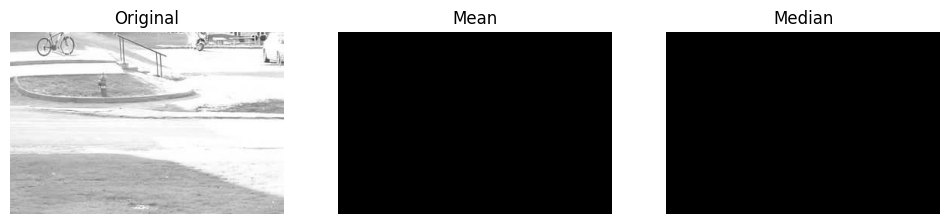

In [40]:
show_sequence(results, 'gray', 1/300, titles=("Original", "Mean", "Median",))

## 3.4. Aproksymacja średniej i mediany (tzw. sigma-delta)

In [5]:
def approx_method(
    sequence: Sequence[MatLike],
    func: FuncType = FuncType.MEAN,
    alpha: float = 1/67,
    bg_sequence: list[MatLike] = [],
) -> Sequence[MatLike]:
    assert len(sequence[0].shape) == 2, "Images must have only one channel"
    bg = sequence[0]
    diff_results = []
    for frame in sequence:
        match func:
            case FuncType.MEAN:
                bg = alpha*frame + (1-alpha)*bg
            case FuncType.MEDIAN:
                bg[bg<frame] = bg[bg<frame]+1
                bg[bg>frame] = bg[bg>frame]-1
        diff = cv2.absdiff(frame.astype(np.uint8), bg.astype(np.uint8))
        diff_results.append(diff)
        bg_sequence.append(cv2.absdiff(bg.astype(np.uint8), sequence[0].astype(np.uint8)))
    binary_result = [cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)[1]*255 for diff in diff_results]
    median_result = [cv2.medianBlur(bin, 3) for bin in binary_result]
    close_result = [cv2.morphologyEx(median, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)), iterations=2) for median in median_result]
    return [r*255 for r in close_result]

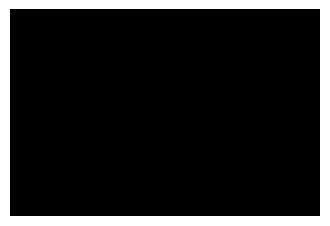

In [51]:
pedestrian_approx_result = approx_method(pedestrian_sequence, func=FuncType.MEDIAN)
show_sequence(pedestrian_approx_result, 'gray', 1/60)

In [6]:
def pipeline_3_2(dataset: DataSet) -> tuple[Sequence[MatLike], ...]:
    dataset_start, dataset_stop = load_roi(dataset)
    dataset_sequence = load_img_sequence(dataset, cv2.IMREAD_GRAYSCALE)
    dataset_sequence = dataset_sequence[dataset_start: dataset_stop+1]
    dataset_groundtruth = load_img_sequence_results(dataset)
    dataset_groundtruth = dataset_groundtruth[dataset_start: dataset_stop+1]

    dataset_mean_background = []
    dataset_mean_result = approx_method(dataset_sequence, bg_sequence=dataset_mean_background)
    dataset_median_background = []
    dataset_median_result = approx_method(dataset_sequence, bg_sequence=dataset_median_background, func=FuncType.MEDIAN)

    mean_metrics = Metrics.compare_sequences(dataset_mean_result, dataset_groundtruth)
    median_metrics = Metrics.compare_sequences(dataset_median_result, dataset_groundtruth)

    for method, metrics in zip(("Mean", "Median",), (mean_metrics, median_metrics,), strict=True):
        print(f"Results for {method}")
        print(f"\t {metrics.precision() = :.2f}")
        print(f"\t {metrics.recall() = :.2f}")
        print(f"\t {metrics.f1() = :.2f}")

    return (dataset_sequence, dataset_mean_result, dataset_mean_background, dataset_median_result, dataset_median_background)


In [ ]:
results = pipeline_3_2(DataSet.OFFICE)

In [ ]:
show_sequence(results, 'gray', 1/250, titles=("Original", "Mean", "Median",))

In [55]:
results = pipeline_3_2(DataSet.HIGHWAY)

Results for Mean
	 metrics.precision() = 0.58
	 metrics.recall() = 0.99
	 metrics.f1() = 0.73
Results for Median
	 metrics.precision() = 0.70
	 metrics.recall() = 0.98
	 metrics.f1() = 0.82


In [118]:
results = pipeline_3_2(DataSet.PEDESTRIAN)

Results for Mean
	 metrics.precision() = 0.54
	 metrics.recall() = 0.98
	 metrics.f1() = 0.70
Results for Median
	 metrics.precision() = 0.56
	 metrics.recall() = 0.98
	 metrics.f1() = 0.71


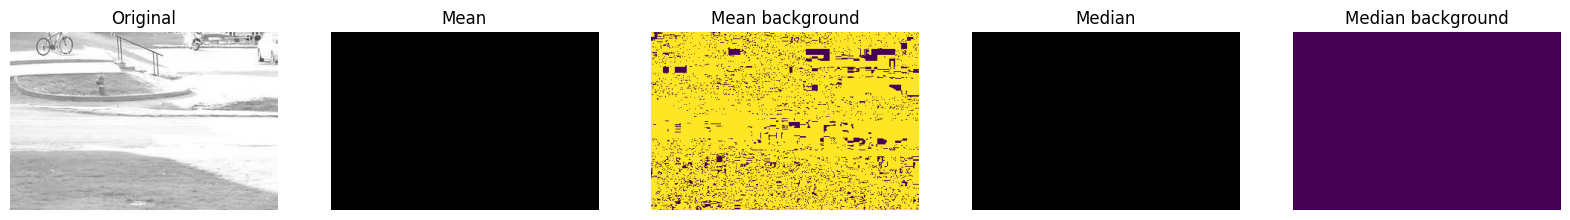

In [110]:
show_sequence(results, ('gray', 'gray', None, 'gray', None), 1/250, titles=("Original", "Mean", "Mean background", "Median", "Median background",))

## 3.5. Polityka aktualizacji

In [7]:
def conservative_approx_method(
    sequence: Sequence[MatLike],
    func: FuncType = FuncType.MEAN,
    alpha: float = 1/67,
    bg_sequence: list[MatLike] = [],
) -> Sequence[MatLike]:
    assert len(sequence[0].shape) == 2, "Images must have only one channel"
    bg = sequence[0]
    results = []
    for frame in sequence:
        bg_update_mask = results[-1]==0 if len(results)>0 else np.ones_like(frame, dtype=np.bool)
        match func:
            case FuncType.MEAN:
                bg[bg_update_mask] = alpha*frame[bg_update_mask] + (1-alpha)*bg[bg_update_mask]
            case FuncType.MEDIAN:
                bg += (bg < frame) * bg_update_mask
                bg -= (bg > frame) * bg_update_mask
        bg_sequence.append(cv2.absdiff(bg, sequence[0]))
        diff = cv2.absdiff(frame.astype(np.uint8), bg.astype(np.uint8))
        binary = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)[1]
        median = cv2.medianBlur(binary, 3)
        close = cv2.morphologyEx(median, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)), iterations=2)
        results.append(close)
    return results

In [8]:
def pipeline_3_3(dataset: DataSet) -> tuple[Sequence[MatLike], ...]:
    dataset_start, dataset_stop = load_roi(dataset)
    dataset_sequence = load_img_sequence(dataset, cv2.IMREAD_GRAYSCALE)
    dataset_sequence = dataset_sequence[dataset_start: dataset_stop+1]
    dataset_groundtruth = load_img_sequence_results(dataset)
    dataset_groundtruth = dataset_groundtruth[dataset_start: dataset_stop+1]

    dataset_mean_background = []
    dataset_mean_result = conservative_approx_method(dataset_sequence, bg_sequence=dataset_mean_background)
    dataset_median_background = []
    dataset_median_result = conservative_approx_method(dataset_sequence, bg_sequence=dataset_median_background, func=FuncType.MEDIAN)

    mean_metrics = Metrics.compare_sequences(dataset_mean_result, dataset_groundtruth)
    median_metrics = Metrics.compare_sequences(dataset_median_result, dataset_groundtruth)

    for method, metrics in zip(("Mean", "Median",), (mean_metrics, median_metrics,), strict=True):
        print(f"Results for {method}")
        print(f"\t {metrics.precision() = :.2f}")
        print(f"\t {metrics.recall() = :.2f}")
        print(f"\t {metrics.f1() = :.2f}")

    return (dataset_sequence, dataset_mean_result, dataset_mean_background, dataset_median_result, dataset_median_background)

In [123]:
results = pipeline_3_3(DataSet.PEDESTRIAN)

Results for Mean
	 metrics.precision() = 0.51
	 metrics.recall() = 0.99
	 metrics.f1() = 0.67
Results for Median
	 metrics.precision() = 0.55
	 metrics.recall() = 0.98
	 metrics.f1() = 0.71


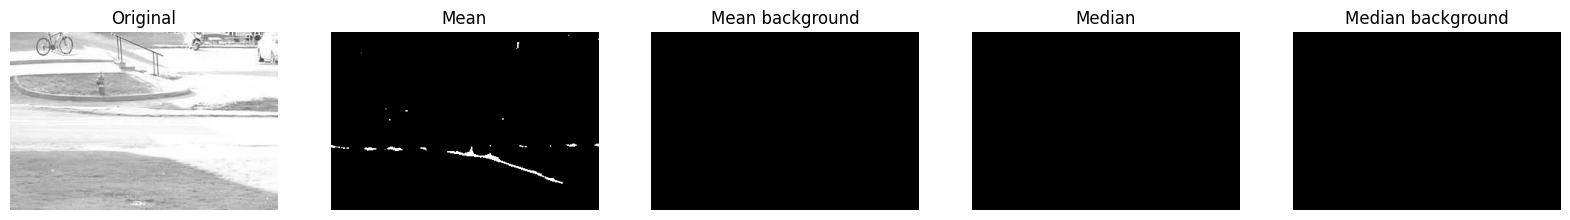

In [124]:
show_sequence(results, 'gray', 1/250, titles=("Original", "Mean", "Mean background", "Median", "Median background",))

In [111]:
results = pipeline_3_3(DataSet.HIGHWAY)

Results for Mean
	 metrics.precision() = 0.34
	 metrics.recall() = 0.99
	 metrics.f1() = 0.50
Results for Median
	 metrics.precision() = 0.17
	 metrics.recall() = 0.99
	 metrics.f1() = 0.28


In [126]:
results = pipeline_3_3(DataSet.OFFICE)

Results for Mean
	 metrics.precision() = 0.30
	 metrics.recall() = 0.97
	 metrics.f1() = 0.46
Results for Median
	 metrics.precision() = 0.72
	 metrics.recall() = 0.96
	 metrics.f1() = 0.83


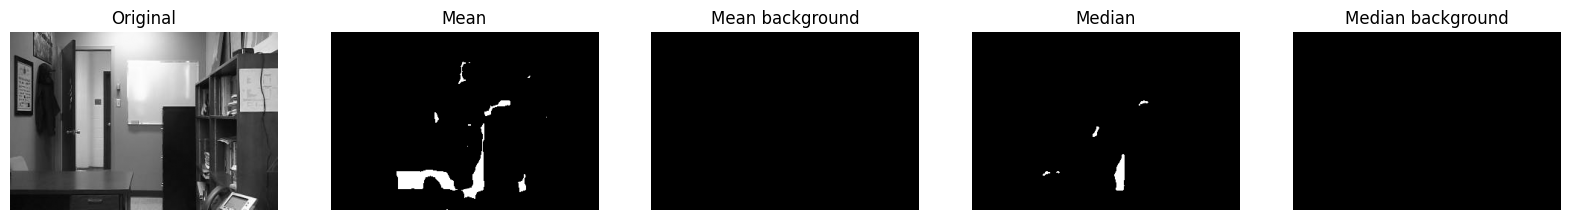

In [127]:
show_sequence(results, 'gray', 1/250, titles=("Original", "Mean", "Mean background", "Median", "Median background",))

## 3.6. OpenCV – GMM/MOG

In [47]:
def pipeline_3_4(dataset: DataSet) -> tuple[Sequence[MatLike], ...]:
    dataset_start, dataset_stop = load_roi(dataset)
    dataset_sequence = load_img_sequence(dataset, cv2.IMREAD_GRAYSCALE)
    dataset_sequence = dataset_sequence[dataset_start: dataset_stop+1]
    dataset_groundtruth = load_img_sequence_results(dataset)
    dataset_groundtruth = dataset_groundtruth[dataset_start: dataset_stop+1]

    subtractor = cv2.createBackgroundSubtractorMOG2(detectShadows=False, history=500, varThreshold=40)

    dataset_result = [subtractor.apply(img, learningRate=0.005) for img in dataset_sequence]

    mean_metrics = Metrics.compare_sequences(dataset_result, dataset_groundtruth)

    for method, metrics in zip(("GMM",), (mean_metrics,), strict=True):
        print(f"Results for {method}")
        print(f"\t {metrics.precision() = :.2f}")
        print(f"\t {metrics.recall() = :.2f}")
        print(f"\t {metrics.f1() = :.2f}")

    return (dataset_sequence, dataset_result)

In [48]:
results = pipeline_3_4(DataSet.PEDESTRIAN)

Results for GMM
	 metrics.precision() = 0.49
	 metrics.recall() = 0.92
	 metrics.f1() = 0.64


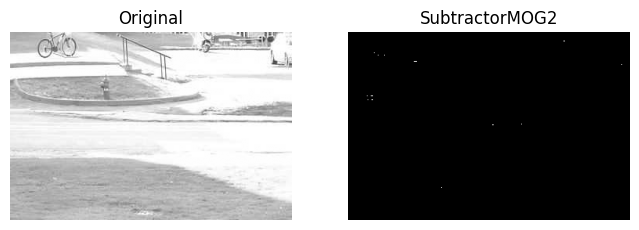

In [49]:
show_sequence(results, 'gray', 1/250, titles=("Original", "SubtractorMOG2",))

## 3.7. OpenCV – KNN

In [69]:
def pipeline_3_5(dataset: DataSet) -> tuple[Sequence[MatLike], ...]:
    dataset_start, dataset_stop = load_roi(dataset)
    dataset_sequence = load_img_sequence(dataset, cv2.IMREAD_GRAYSCALE)
    dataset_sequence = dataset_sequence[dataset_start: dataset_stop+1]
    dataset_sequence, frame_shape = normalize_frame_size(dataset_sequence)
    dataset_groundtruth = load_img_sequence_results(dataset)
    dataset_groundtruth = dataset_groundtruth[dataset_start: dataset_stop+1]
    if any(img.shape[:2] != frame_shape for img in dataset_groundtruth):
        raise ValueError("Ground-truth frame dimensions must match the normalized input frame dimensions")

    subtractor = cv2.createBackgroundSubtractorKNN(detectShadows=False)

    dataset_result = [subtractor.apply(img) for img in dataset_sequence]

    mean_metrics = Metrics.compare_sequences(dataset_result, dataset_groundtruth)

    for method, metrics in zip(("KNN",), (mean_metrics,), strict=True):
        print(f"Results for {method}")
        print(f"\t {metrics.precision() = :.2f}")
        print(f"\t {metrics.recall() = :.2f}")
        print(f"\t {metrics.f1() = :.2f}")

    return (dataset_sequence, dataset_result)

In [70]:
results = pipeline_3_5(DataSet.PEDESTRIAN)

Results for KNN
	 metrics.precision() = 0.42
	 metrics.recall() = 0.92
	 metrics.f1() = 0.58


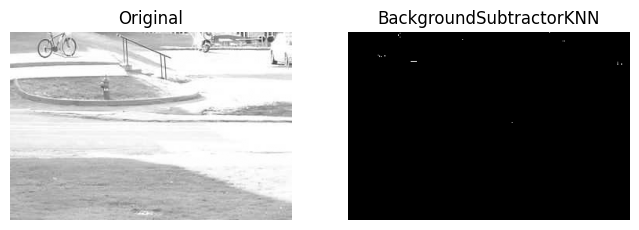

In [71]:
show_sequence(results, 'gray', 1/250, titles=("Original", "BackgroundSubtractorKNN",))